In [ ]:
import yfinance as yf

import pandas as pd
import numpy as np

import math

import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams

from sklearn.preprocessing import MinMaxScaler

from keras.layers import LSTM, Dropout, Dense
from keras.models import Sequential
%matplotlib inline
rcParams['figure.figsize'] = 20, 10

In [ ]:
ticker = 'BAJFINANCE.NS'
df = yf.download(ticker, period='5y')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BAJFINANCE.NS,BAJFINANCE.NS,BAJFINANCE.NS,BAJFINANCE.NS,BAJFINANCE.NS,BAJFINANCE.NS
Date,,,,,,
2019-12-24,4070.567871,4139.500000,4180.700195,4125.649902,4158.000000,751979
2019-12-26,4117.375000,4187.100098,4196.450195,4133.250000,4149.950195,1265020
2019-12-27,4181.833008,4252.649902,4260.000000,4192.000000,4198.000000,1126648
2019-12-30,4172.638672,4243.299805,4281.549805,4230.000000,4274.850098,831910
2019-12-31,4164.230957,4234.750000,4266.399902,4218.600098,4247.000000,779608


In [ ]:
df = df.reset_index()
df = df[['Date', 'Adj Close']]
df = df.dropna()
df.shape

(1239, 2)

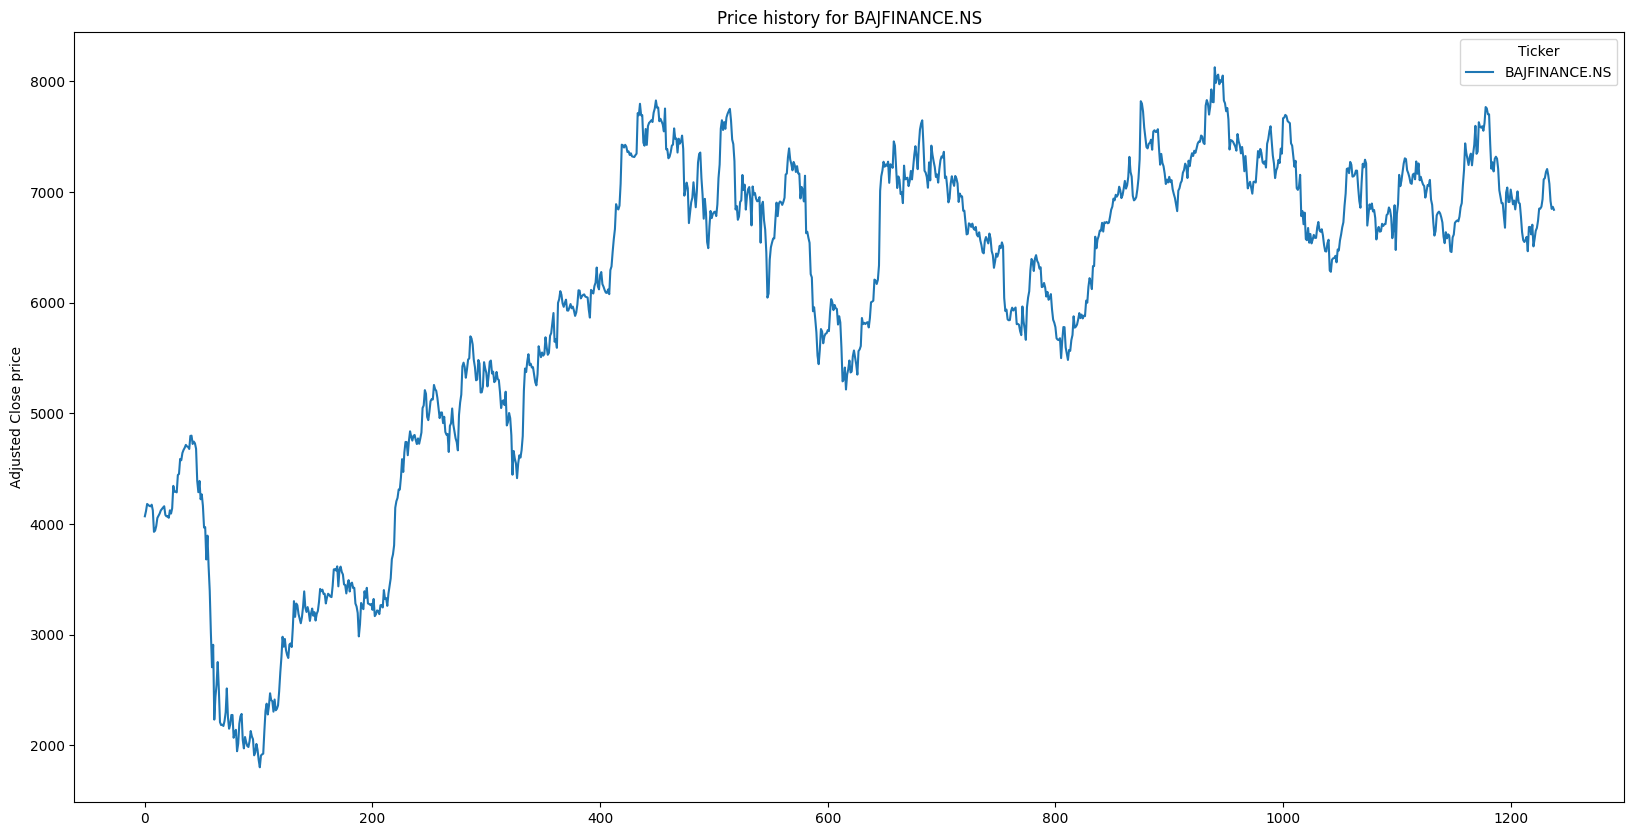

In [ ]:
df['Adj Close'].plot()
plt.ylabel('Adjusted Close price')
plt.title(f'Price history for {ticker}')
plt.show()

In [ ]:
df1 = df['Adj Close']
df1.head()


Ticker,BAJFINANCE.NS
0,4070.567871
1,4117.375000
2,4181.833008
3,4172.638672
4,4164.230957


In [ ]:
df1.rename(columns={'Adj Close': 'Close'}, inplace=True)


<ipython-input-7-a24c1dd734b4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.rename(columns={'Adj Close': 'Close'}, inplace=True)


In [ ]:
prices = df1.values

In [ ]:
prices

array([[4070.56787109],
       [4117.375     ],
       [4181.83300781],
       ...,
       [6848.25      ],
       [6866.70019531],
       [6840.10009766]])

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices.reshape(-1, 1))

In [ ]:
scaled_prices

array([[0.35855587],
       [0.36595612],
       [0.376147  ],
       ...,
       [0.79771017],
       [0.80062716],
       [0.79642166]])

In [ ]:
train_len = math.ceil(len(prices) * 0.8)
train_len

992

In [ ]:

train_data = scaled_prices[0:train_len, :]

In [ ]:
x_train, y_train = [], []

for i in range(60, len(train_data)):
    x_train.append(scaled_prices[i-60:i, 0])
    y_train.append(scaled_prices[i, 0])

In [ ]:
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [ ]:
test_data = scaled_prices[train_len-60:, :]
x_test = []
y_test = prices[train_len:]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

model = Sequential()

model.add(Input(shape=(x_train.shape[1], 1)))

model.add(LSTM(100, return_sequences=True))

model.add(LSTM(100, return_sequences=False))

model.add(Dense(25))

model.add(Dense(1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100)                 │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           2,525 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 123,751 (483.40 KB)

 Trainable params: 123,751 (483.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=1, epochs=3)

Epoch 1/3
932/932 ━━━━━━━━━━━━━━━━━━━━ 55s 56ms/step - loss: 0.0180
Epoch 2/3
932/932 ━━━━━━━━━━━━━━━━━━━━ 53s 57ms/step - loss: 0.0018
Epoch 3/3
932/932 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - loss: 0.0014


In [ ]:
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
rmse = np.sqrt(np.mean(predictions - y_test)**2)
rmse

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


342.5767372532895

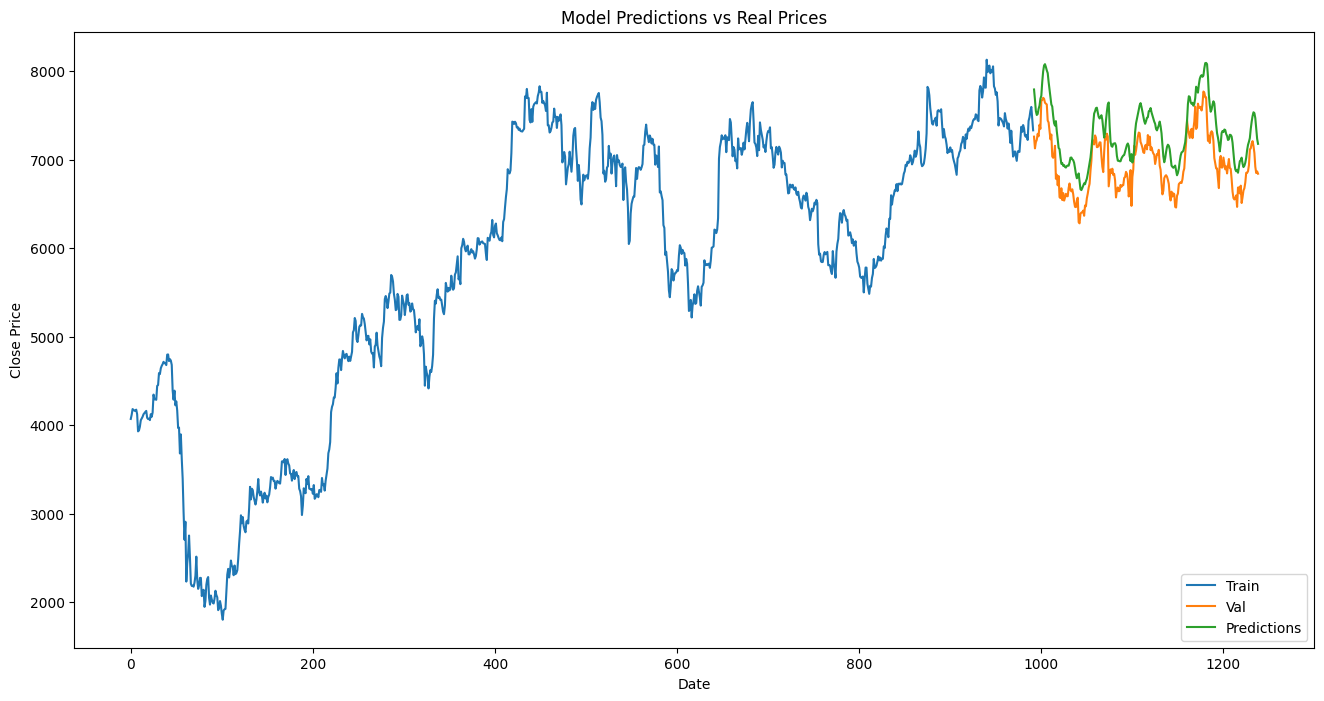

In [ ]:

data = df[['Date', 'Adj Close']]  # Select 'Date' and 'Adj Close' from df
data.rename(columns={'Adj Close': 'Close'}, inplace=True) # Rename 'Adj Close' to 'Close'
train = data[:train_len].copy()
validation = data[train_len:].copy()
validation['Predictions'] = predictions
plt.figure(figsize=(16, 8))
plt.title('Model Predictions vs Real Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.plot(train['Close']) # Plot 'Close' from train
plt.plot(validation[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()


In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score , r2_score

X = data[['Date']].copy()  # Create a copy to avoid SettingWithCopyWarning
X['Date'] = X['Date'].apply(lambda date: date.toordinal())  # Convert Date to ordinal
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_predictions)
print(f"Linear Regression MSE: {lr_mse}")

knn_model = KNeighborsRegressor(n_neighbors=3)  # Changed to KNeighborsRegressor
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
knn_r2 = r2_score(y_test, knn_predictions) # Calculate R-squared for regression
print(f"KNN R-squared: {knn_r2}") # Print R-square



Linear Regression MSE: 950019.0257994361
KNN R-squared: 0.9939919391194587


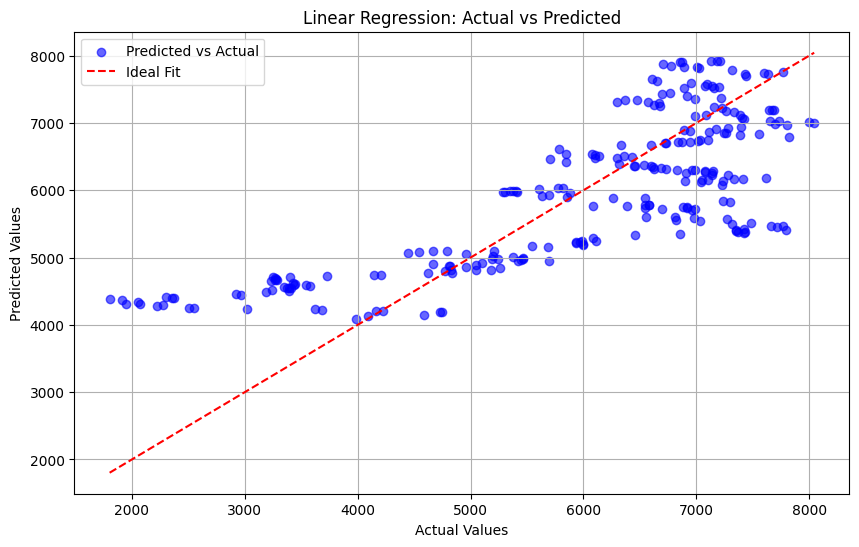

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_predictions, alpha=0.6, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import requests
import yfinance as yf
from textblob import TextBlob
from datetime import datetime


def fetch_news(company_name):
    api_key = 'ccb2a2a7545f452aaf96259ca4d5b1e6'
    url = f'https://newsapi.org/v2/everything?q={company_name}+CEO+death&apiKey={api_key}'
    response = requests.get(url)


    if response.status_code != 200:
        print(f"Failed to fetch news. Status code: {response.status_code}")
        return []

    news_data = response.json()
    return news_data.get('articles', [])


def fetch_stock_data(ticker):
    stock = yf.Ticker(ticker)
    stock_data = stock.history(period="6mo")
    return stock_data


def analyze_sentiment(news_articles):
    sentiment_score = 0
    for article in news_articles:
        text = article.get('title', '') + " " + article.get('description', '')
        blob = TextBlob(text)
        sentiment_score += blob.sentiment.polarity
    average_sentiment = sentiment_score / len(news_articles) if news_articles else 0
    return average_sentiment


def make_investment_decision(stock_data, sentiment_score):
    stock_trend = "down" if stock_data['Close'].iloc[-1] < stock_data['Close'].iloc[0] else "up"

    if sentiment_score < 0 and stock_trend == "down":
        return "Not a good time to invest. The CEO's death may lead to further uncertainty."
    elif sentiment_score > 0 and stock_trend == "down":
        return "The market may be overreacting. It might be a good time to buy at a lower price."
    elif sentiment_score > 0 and stock_trend == "up":
        return "The company is showing resilience. It may be a good time to invest."
    else:
        return "No clear trend. It's best to wait for more information."
def main(company_name, ticker):
    news_articles = fetch_news(company_name)
    if not news_articles:
        print("No news found for the specified company.")
        return

    sentiment_score = analyze_sentiment(news_articles)

    stock_data = fetch_stock_data(ticker)
    if stock_data.empty:
        print("Failed to fetch stock data.")
        return
    decision = make_investment_decision(stock_data, sentiment_score)

    print(f"Sentiment Score: {sentiment_score:.2f}")
    print(f"Stock Trend: {'Down' if stock_data['Close'].iloc[-1] < stock_data['Close'].iloc[0] else 'Up'}")
    print(f"Investment Recommendation: {decision}")
if __name__ == "__main__":
    company_name = "UnitedHealthcare"
    ticker = "UNH"
    main(company_name, ticker)


Sentiment Score: 0.05
Stock Trend: Up
Investment Recommendation: The company is showing resilience. It may be a good time to invest.
